# 9단계 · 부분 매수/매도 전략 (Partial Position Sizing)

## 핵심 질문: "시장 상황에 따라 부분 매수/매도가 더 낫지 않을까?"

08번 Walk-Forward 결과(-15.83%)를 보면 두 가지 문제가 명확하다:
- **진입**: 국면별 고정 비중(100/70/50%) → ADX 강도가 낮을 때도 동일한 비율로 베팅
- **청산**: 신호 발생 즉시 전량 매도 → 단기 변동에 과도하게 반응

---

## 08번 vs 09번 전략 비교

| 구분 | 08번 (고정 비중) | 09번 (동적 비중) |
|------|-----------------|----------------|
| **진입 비중** | 국면별 고정 (STRONG=100%, WEAK=70%, RANGE=50%) | ADX 강도 비례 동적 결정 |
| **청산 방식** | 신호 발생 즉시 전량 매도 (0%) | 단계적 (WEAK_BEAR→30% 유지, STRONG_BEAR→0%) |
| **WF 파라미터** | `adx_threshold` 1개 | `adx_threshold` + `adx_scale` 2개 |
| **포지션 종류** | 이산값 (0/0.5/0.7/1.0) | 연속값 (0.3 ~ 1.0) |

### 09번 핵심 아이디어

```
[진입 비중]  ADX=threshold → 30% (확신 약) ~ ADX=threshold+scale → 100% (확신 강)

[단계적 청산] STRONG_BULL ──→ WEAK_BEAR: 30% 유지 (반등 가능성 보존)
             WEAK_BEAR   ──→ STRONG_BEAR: 0% 전량 청산 (추세 하락 확정)
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest import optimizer
from vbt_backtest.strategies.combined import ma_regime_strategy, partial_sizing_strategy

# ── 데이터 로드 (08번과 동일) ─────────────────────────────────────────────────
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'
FEES     = 0.0015
SLIPPAGE = 0.001

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일


---
## 1단계 · 08번 Walk-Forward 재실행 (비교 기준)

08번 결과를 기준선으로 사용하기 위해 동일한 조건으로 재실행한다.

In [2]:
# ── 08번 Walk-Forward (adx_threshold 단일 파라미터) ──────────────────────────
def regime_fn_08(close, high, low, volume, adx_threshold=25.0,
                 fees=FEES, slippage=SLIPPAGE):
    return ma_regime_strategy.run_backtest(
        close, high, low, volume,
        adx_threshold=adx_threshold,
        fees=fees, slippage=slippage,
    )

print('08번 Walk-Forward 실행 중...')
wf08 = optimizer.walk_forward(
    close,
    regime_fn_08,
    param_grid={'adx_threshold': [15, 18, 20, 22, 25, 28, 30, 35]},
    train_months=12,
    test_months=6,
    fees=FEES,
    slippage=SLIPPAGE,
    metric='sharpe_ratio',
    warmup_days=150,
    high=high, low=low, volume=volume,
)

wf08_equity = wf08['equity_curve']
wf08_start  = wf08_equity.index[0]
wf08_end    = wf08_equity.index[-1]

n_years_08 = (wf08_end - wf08_start).days / 365.25
wf08_total  = wf08_equity.iloc[-1] / wf08_equity.iloc[0] - 1
wf08_cagr   = (wf08_equity.iloc[-1] / wf08_equity.iloc[0]) ** (1 / n_years_08) - 1
wf08_daily  = wf08_equity.pct_change().dropna()
wf08_sharpe = wf08_daily.mean() / wf08_daily.std() * np.sqrt(252)
wf08_mdd    = (wf08_equity / wf08_equity.cummax() - 1).min()

print(f'완료: {wf08["n_windows"]}개 윈도우')
print(f'08번 WF 총수익률: {wf08_total:.2%}  CAGR: {wf08_cagr:.2%}  Sharpe: {wf08_sharpe:.2f}  MDD: {wf08_mdd:.2%}')

08번 Walk-Forward 실행 중...
완료: 9개 윈도우
08번 WF 총수익률: -15.83%  CAGR: -3.76%  Sharpe: -0.56  MDD: -17.90%


---
## 2단계 · 09번 핵심 아이디어 시각화

### ADX 비례 진입 비중

08번은 국면이 결정되면 비중이 고정된다. 09번은 **ADX 값 자체**를 비중 결정에 활용한다.

```
비중 = clip(min_size + (1 - min_size) × (ADX - threshold) / scale, min_size, 1.0)
```

| ADX 값 | threshold=20, scale=30 | threshold=25, scale=30 |
|--------|----------------------|----------------------|
| 15     | 30% (min)            | 30% (min)            |
| 25     | 65%                  | 30% (min)            |
| 35     | 97%                  | 65%                  |
| 50     | 100% (max)           | 100% (max)           |

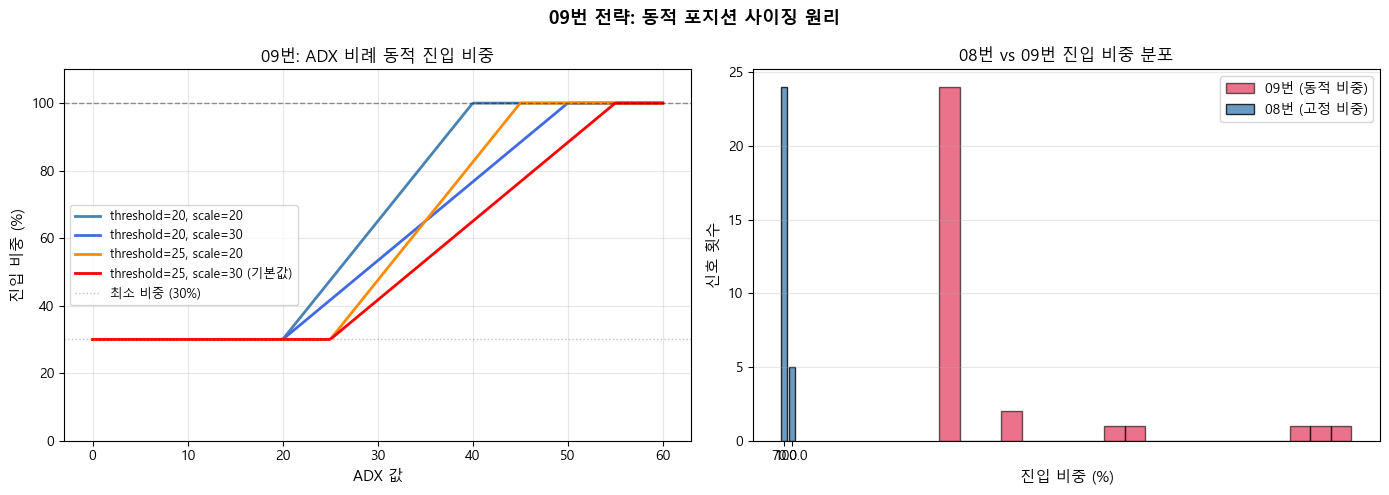

08번 진입 신호 비중값 분포: {70.0: 24, 100.0: 5}
09번 진입 신호 비중값 범위: 0.21 ~ 0.77  (평균: 0.28)


In [3]:
adx_range = np.linspace(0, 60, 300)

def adx_ratio_fn(adx, threshold, scale, min_size=0.3):
    return np.clip(min_size + (1 - min_size) * (adx - threshold) / scale, min_size, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 다양한 (threshold, scale) 조합
combos = [
    (20, 20, 'steelblue',  'threshold=20, scale=20'),
    (20, 30, 'royalblue',  'threshold=20, scale=30'),
    (25, 20, 'darkorange', 'threshold=25, scale=20'),
    (25, 30, 'red',        'threshold=25, scale=30 (기본값)'),
]

for th, sc, color, label in combos:
    y = adx_ratio_fn(adx_range, th, sc)
    axes[0].plot(adx_range, y * 100, color=color, linewidth=2, label=label)

axes[0].axhline(100, color='black', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axhline(30,  color='gray',  linestyle=':',  alpha=0.5, linewidth=1, label='최소 비중 (30%)')
axes[0].set_xlabel('ADX 값', fontsize=11)
axes[0].set_ylabel('진입 비중 (%)', fontsize=11)
axes[0].set_title('09번: ADX 비례 동적 진입 비중', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 110)

# 오른쪽: 08번 vs 09번 비중 비교 (실제 ADX 분포 위에)
_, _, size_08, detail_08 = ma_regime_strategy.make_signals(
    close, high, low, volume, adx_threshold=25.0
)
_, _, size_09, detail_09 = partial_sizing_strategy.make_signals(
    close, high, low, volume, adx_threshold=25.0, adx_scale=30.0
)

# 진입 신호만 (0 초과)
s08_pos = size_08.dropna()
s08_pos = s08_pos[s08_pos > 0]
s09_pos = size_09.dropna()
s09_pos = s09_pos[s09_pos > 0]

val_counts_08 = (s08_pos * 100).round(0).value_counts().sort_index()

axes[1].bar(
    val_counts_08.index.astype(str),
    val_counts_08.values,
    color='steelblue', alpha=0.8, edgecolor='black', label='08번 (고정 비중)'
)
axes[1].hist(
    s09_pos * 100, bins=20, alpha=0.6, color='crimson', edgecolor='black',
    label='09번 (동적 비중)', orientation='vertical'
)
axes[1].set_xlabel('진입 비중 (%)', fontsize=11)
axes[1].set_ylabel('신호 횟수', fontsize=11)
axes[1].set_title('08번 vs 09번 진입 비중 분포', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('09번 전략: 동적 포지션 사이징 원리', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'08번 진입 신호 비중값 분포: {dict(val_counts_08)}')
print(f'09번 진입 신호 비중값 범위: {s09_pos.min():.2f} ~ {s09_pos.max():.2f}  (평균: {s09_pos.mean():.2f})')

---
## 3단계 · 단계적 청산 메커니즘 확인

=== 단계적 청산 비교 ===
08번 즉시전량청산 발동 횟수: 6회  (WEAK_BEAR OR STRONG_BEAR 진입 시 전량 0%)
09번 부분청산 발동 횟수   : 3회  (WEAK_BEAR → 30% 축소)
09번 전량청산 발동 횟수   : 6회  (STRONG_BEAR → 0%)

=== 국면별 일수 분포 ===
  횡보/조정     :  537일 (36.4%)
  약한 상승     :  320일 (21.7%)
  약한 하락     :  259일 (17.6%)
  강한 상승     :  258일 (17.5%)
  강한 하락     :  101일 (6.8%)


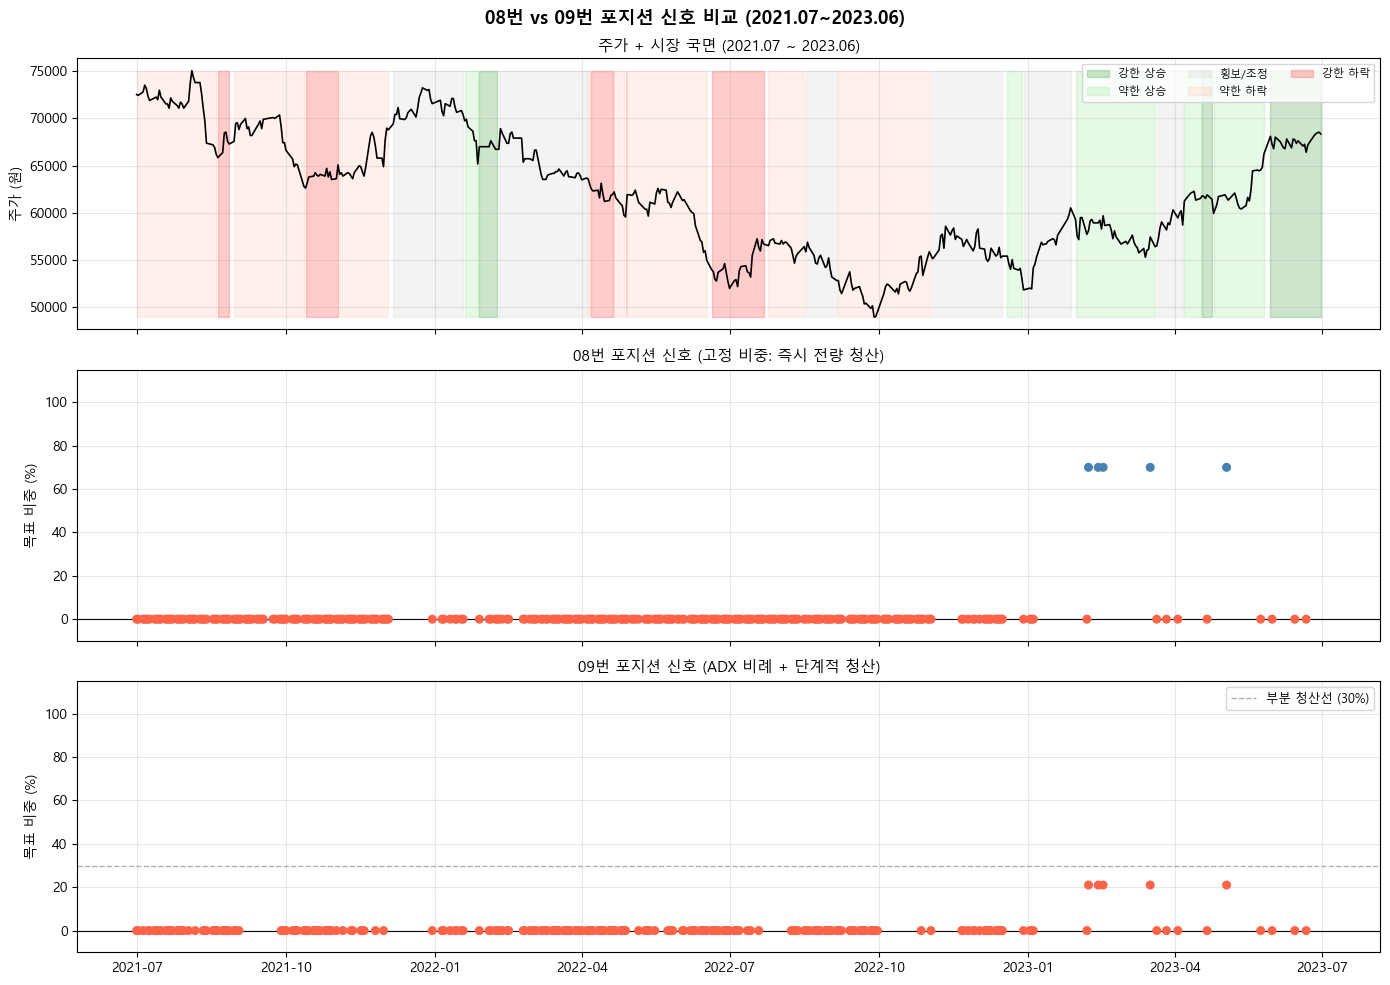

In [4]:
# WEAK_BEAR / STRONG_BEAR 전환 횟수 비교
regime_08 = detail_08['regime']
regime_09 = detail_09['regime']

wb_start_09 = detail_09['weak_bear_start']
sb_start_09 = detail_09['strong_bear_start']

# 08번 즉시 청산 횟수 (bear_exit 발동)
bear_exit_08 = (detail_08['masks']['WEAK_BEAR'] | detail_08['masks']['STRONG_BEAR'])
bear_transition_08 = bear_exit_08 & ~bear_exit_08.shift(1).fillna(False)

print('=== 단계적 청산 비교 ===')
print(f'08번 즉시전량청산 발동 횟수: {bear_transition_08.sum()}회  (WEAK_BEAR OR STRONG_BEAR 진입 시 전량 0%)')
print(f'09번 부분청산 발동 횟수   : {wb_start_09.sum()}회  (WEAK_BEAR → 30% 축소)')
print(f'09번 전량청산 발동 횟수   : {sb_start_09.sum()}회  (STRONG_BEAR → 0%)')
print()

# 국면별 일수 분포
regime_counts = regime_08.value_counts()
total_days = len(regime_08)
print('=== 국면별 일수 분포 ===')
for r, cnt in regime_counts.items():
    print(f'  {r:10s}: {cnt:4d}일 ({cnt/total_days:.1%})')

# 단계적 청산 예시 타임라인 (2022년 하락장 구간)
sample_start = '2021-07-01'
sample_end   = '2023-06-30'

s_close  = close.loc[sample_start:sample_end]
s_reg    = regime_09.loc[sample_start:sample_end]
s_size08 = size_08.loc[sample_start:sample_end]
s_size09 = size_09.loc[sample_start:sample_end]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 국면 색상
from vbt_backtest.strategies.combined.ma_regime_strategy import REGIME_COLORS
for regime_name, (color, alpha) in REGIME_COLORS.items():
    mask = (s_reg == regime_name)
    if mask.any():
        axes[0].fill_between(s_close.index, s_close.min(), s_close.max(),
                             where=mask, alpha=alpha, color=color, label=regime_name)
axes[0].plot(s_close, color='black', linewidth=1.2)
axes[0].set_title('주가 + 시장 국면 (2021.07 ~ 2023.06)', fontsize=11)
axes[0].set_ylabel('주가 (원)')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)
axes[0].grid(True, alpha=0.3)

# 08번 포지션 신호
axes[1].scatter(s_size08.dropna().index, s_size08.dropna() * 100,
                c=['steelblue' if v > 0 else 'tomato' for v in s_size08.dropna()],
                s=30, zorder=5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('08번 포지션 신호 (고정 비중: 즉시 전량 청산)', fontsize=11)
axes[1].set_ylabel('목표 비중 (%)')
axes[1].set_ylim(-10, 115)
axes[1].grid(True, alpha=0.3)

# 09번 포지션 신호
colors_09 = []
for v in s_size09.dropna():
    if v >= 0.6:    colors_09.append('green')
    elif v >= 0.3:  colors_09.append('steelblue')
    else:           colors_09.append('tomato')

axes[2].scatter(s_size09.dropna().index, s_size09.dropna() * 100,
                c=colors_09, s=30, zorder=5)
axes[2].axhline(30, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='부분 청산선 (30%)')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('09번 포지션 신호 (ADX 비례 + 단계적 청산)', fontsize=11)
axes[2].set_ylabel('목표 비중 (%)')
axes[2].set_ylim(-10, 115)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('08번 vs 09번 포지션 신호 비교 (2021.07~2023.06)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4단계 · 09번 Walk-Forward 실행

- **최적화 파라미터**: `adx_threshold` × `adx_scale` (2D 그리드)
- **탐색 범위**: threshold [15, 18, 20, 22, 25, 28, 30, 35] × scale [10, 20, 30, 40]
- **최적화 기준**: 샤프비율
- **학습/검증**: 12개월 / 6개월 (08번과 동일)

In [5]:
def regime_fn_09(close, high, low, volume,
                 adx_threshold=25.0, adx_scale=30.0,
                 fees=FEES, slippage=SLIPPAGE):
    return partial_sizing_strategy.run_backtest(
        close, high, low, volume,
        adx_threshold=adx_threshold,
        adx_scale=adx_scale,
        fees=fees, slippage=slippage,
    )

print('09번 Walk-Forward 실행 중... (2D 그리드 탐색)')
wf09 = optimizer.walk_forward(
    close,
    regime_fn_09,
    param_grid={
        'adx_threshold': [15, 18, 20, 22, 25, 28, 30, 35],
        'adx_scale':     [10, 20, 30, 40],
    },
    train_months=12,
    test_months=6,
    fees=FEES,
    slippage=SLIPPAGE,
    metric='sharpe_ratio',
    warmup_days=150,
    high=high, low=low, volume=volume,
)

wf09_equity = wf09['equity_curve']
wf09_start  = wf09_equity.index[0]
wf09_end    = wf09_equity.index[-1]

n_years_09 = (wf09_end - wf09_start).days / 365.25
wf09_total  = wf09_equity.iloc[-1] / wf09_equity.iloc[0] - 1
wf09_cagr   = (wf09_equity.iloc[-1] / wf09_equity.iloc[0]) ** (1 / n_years_09) - 1
wf09_daily  = wf09_equity.pct_change().dropna()
wf09_sharpe = wf09_daily.mean() / wf09_daily.std() * np.sqrt(252)
wf09_mdd    = (wf09_equity / wf09_equity.cummax() - 1).min()

print(f'완료: {wf09["n_windows"]}개 윈도우')
print(f'09번 WF 총수익률: {wf09_total:.2%}  CAGR: {wf09_cagr:.2%}  Sharpe: {wf09_sharpe:.2f}  MDD: {wf09_mdd:.2%}')

09번 Walk-Forward 실행 중... (2D 그리드 탐색)
완료: 9개 윈도우
09번 WF 총수익률: 1.57%  CAGR: 0.35%  Sharpe: 0.14  MDD: -4.99%


---
## 5단계 · 구간별 최적 파라미터 비교

In [6]:
rows_08, rows_09 = [], []

for i, (w08, w09) in enumerate(zip(wf08['windows'], wf09['windows'])):
    ret08 = (
        (w08['test_value'].iloc[-1] / w08['test_value'].iloc[0] - 1)
        if w08['test_value'] is not None and len(w08['test_value']) > 0 else float('nan')
    )
    ret09 = (
        (w09['test_value'].iloc[-1] / w09['test_value'].iloc[0] - 1)
        if w09['test_value'] is not None and len(w09['test_value']) > 0 else float('nan')
    )
    rows_08.append({
        '윈도우': f'W{i+1:02d}',
        '검증 기간': f"{w08['test_start'].strftime('%y.%m')}~{w08['test_end'].strftime('%y.%m')}",
        '최적 ADX': w08['best_params']['adx_threshold'],
        '학습 Sharpe': round(w08['best_score'], 3),
        '검증 수익률': f'{ret08:.2%}' if not np.isnan(ret08) else 'N/A',
    })
    rows_09.append({
        '윈도우': f'W{i+1:02d}',
        '최적 threshold': w09['best_params']['adx_threshold'],
        '최적 scale': w09['best_params']['adx_scale'],
        '학습 Sharpe': round(w09['best_score'], 3),
        '검증 수익률': f'{ret09:.2%}' if not np.isnan(ret09) else 'N/A',
    })

df08 = pd.DataFrame(rows_08).set_index('윈도우')
df09 = pd.DataFrame(rows_09).set_index('윈도우')

print('=== 08번 구간별 결과 (adx_threshold 단일) ===')
print(df08.to_string())
print()
print('=== 09번 구간별 결과 (adx_threshold + adx_scale 2D) ===')
print(df09.to_string())

=== 08번 구간별 결과 (adx_threshold 단일) ===
           검증 기간  최적 ADX  학습 Sharpe  검증 수익률
윈도우                                        
W01  20.01~20.07      35      0.976  -9.73%
W02  20.07~20.12      15     -0.085   5.22%
W03  21.01~21.07      18      2.292  -2.41%
W04  21.07~21.12      15      1.178   0.00%
W05  22.01~22.07      15       -inf   0.00%
W06  22.07~22.12      15       -inf   0.00%
W07  23.01~23.06      15     -0.918  -6.10%
W08  23.07~23.12      22      0.172   5.85%
W09  24.01~24.07      20      2.619  -8.65%

=== 09번 구간별 결과 (adx_threshold + adx_scale 2D) ===
     최적 threshold  최적 scale  학습 Sharpe  검증 수익률
윈도우                                           
W01            35        40      0.501  -4.00%
W02            18        10     -0.043   8.81%
W03            18        40      2.301  -1.68%
W04            15        30      1.361   0.00%
W05            18        10     -0.949   0.00%
W06            18        10       -inf   0.00%
W07            28        10     -0.554   0.21%
W08 

---
## 6단계 · 비교 분석: 4개 전략 자산 곡선

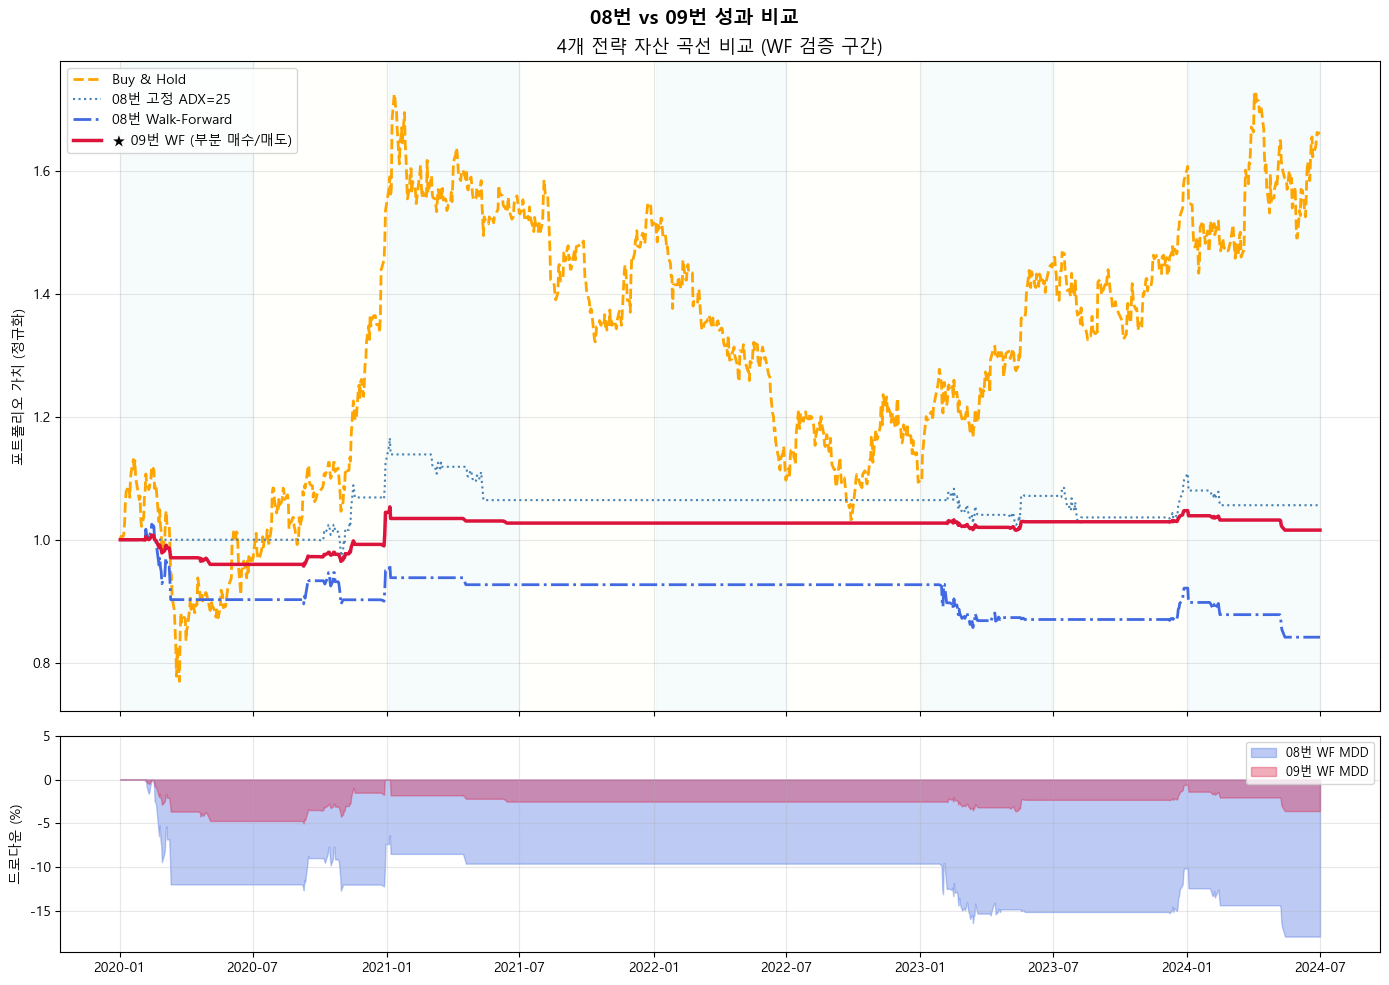

In [7]:
# 공통 기준 기간 (WF 검증 시작 ~ 종료)
common_start = wf08_equity.index[0]
common_end   = min(wf08_equity.index[-1], wf09_equity.index[-1])
close_period = close.loc[common_start:common_end]

# Buy & Hold
bh_e = pd.Series(False, index=close_period.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close_period.index); bh_x.iloc[-1] = True
pf_bh = vbt.Portfolio.from_signals(
    close_period, bh_e, bh_x, fees=FEES, slippage=SLIPPAGE, freq='D'
)
bh_val = pf_bh.value()

# 08번 고정 ADX=25
pf_fixed08 = ma_regime_strategy.run_backtest(
    close_period,
    high.loc[common_start:common_end],
    low.loc[common_start:common_end],
    volume.loc[common_start:common_end],
    adx_threshold=25.0, fees=FEES, slippage=SLIPPAGE,
)
fixed08_val = pf_fixed08.value()

# 정규화 (동일 시작점)
init_val = wf08_equity.iloc[0]

bh_norm      = bh_val / bh_val.iloc[0] * init_val
fixed08_norm = fixed08_val / fixed08_val.iloc[0] * init_val
wf08_plot    = wf08_equity.loc[:common_end]
wf09_plot    = wf09_equity.loc[:common_end]

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(bh_norm,      color='orange',    linewidth=2.0, linestyle='--',  label='Buy & Hold')
ax1.plot(fixed08_norm, color='steelblue', linewidth=1.5, linestyle=':',   label='08번 고정 ADX=25')
ax1.plot(wf08_plot,    color='royalblue', linewidth=2.0, linestyle='-.',  label='08번 Walk-Forward')
ax1.plot(wf09_plot,    color='crimson',   linewidth=2.5, linestyle='-',   label='★ 09번 WF (부분 매수/매도)')

# 검증 구간 배경
for i, w in enumerate(wf09['windows']):
    color = 'lightblue' if i % 2 == 0 else 'lightyellow'
    ax1.axvspan(w['test_start'], min(w['test_end'], common_end), alpha=0.10, color=color)

ax1.set_title('4개 전략 자산 곡선 비교 (WF 검증 구간)', fontsize=13)
ax1.set_ylabel('포트폴리오 가치 (정규화)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# 드로다운 비교 (08 WF vs 09 WF)
dd08 = (wf08_plot / wf08_plot.cummax() - 1) * 100
dd09 = (wf09_plot / wf09_plot.cummax() - 1) * 100

ax2.fill_between(dd08.index, 0, dd08, color='royalblue', alpha=0.35, label='08번 WF MDD')
ax2.fill_between(dd09.index, 0, dd09, color='crimson',   alpha=0.35, label='09번 WF MDD')
ax2.set_ylabel('드로다운 (%)')
ax2.set_ylim(min(dd08.min(), dd09.min()) * 1.1, 5)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('08번 vs 09번 성과 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7단계 · 성과 비교 테이블

In [8]:
n_years_common = (common_end - common_start).days / 365.25

def calc_metrics(equity: pd.Series, n_years: float, label: str) -> dict:
    total  = equity.iloc[-1] / equity.iloc[0] - 1
    cagr   = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1
    dr     = equity.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else float('nan')
    mdd    = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(mdd) if mdd < 0 else float('nan')
    return {
        '전략':          label,
        '총 수익률':     f'{total:.2%}',
        '연평균(CAGR)':  f'{cagr:.2%}',
        '샤프비율':      f'{sharpe:.2f}',
        '최대낙폭(MDD)': f'{mdd:.2%}',
        'Calmar비율':    f'{calmar:.2f}' if not np.isnan(calmar) else 'N/A',
    }

rows_perf = [
    calc_metrics(bh_norm,      n_years_common, 'Buy & Hold'),
    calc_metrics(fixed08_norm, n_years_common, '08번 고정 ADX=25'),
    calc_metrics(wf08_plot,    n_years_common, '08번 Walk-Forward'),
    calc_metrics(wf09_plot,    n_years_common, '★ 09번 WF (부분 매수/매도)'),
]

df_perf = pd.DataFrame(rows_perf).set_index('전략')
print(f'=== 성과 비교 ({common_start.date()} ~ {common_end.date()}) ===')
print(df_perf.to_string())

# 개선 여부 요약
wf08_total_num = wf08_equity.iloc[-1] / wf08_equity.iloc[0] - 1
wf09_total_num = wf09_plot.iloc[-1] / wf09_plot.iloc[0] - 1

print()
print(f'▶ 08번 대비 09번 총수익률 변화: {wf08_total_num:.2%} → {wf09_total_num:.2%}  '
      f'({"↑ 개선" if wf09_total_num > wf08_total_num else "↓ 악화"})')

dd08_min = (wf08_plot / wf08_plot.cummax() - 1).min()
dd09_min = (wf09_plot / wf09_plot.cummax() - 1).min()
print(f'▶ 08번 대비 09번 MDD 변화: {dd08_min:.2%} → {dd09_min:.2%}  '
      f'({"↑ 방어력 개선" if dd09_min > dd08_min else "↓ 방어력 악화"})')

=== 성과 비교 (2020-01-02 ~ 2024-07-01) ===
                       총 수익률 연평균(CAGR)   샤프비율 최대낙폭(MDD) Calmar비율
전략                                                              
Buy & Hold            66.18%    11.96%   0.58   -40.14%     0.30
08번 고정 ADX=25          5.61%     1.22%   0.24   -12.10%     0.10
08번 Walk-Forward     -15.83%    -3.76%  -0.56   -17.90%    -0.21
★ 09번 WF (부분 매수/매도)    1.57%     0.35%   0.14    -4.99%     0.07

▶ 08번 대비 09번 총수익률 변화: -15.83% → 1.57%  (↑ 개선)
▶ 08번 대비 09번 MDD 변화: -17.90% → -4.99%  (↑ 방어력 개선)


---
## 8단계 · 구간별 비교: 하락장에서 부분 청산의 효과

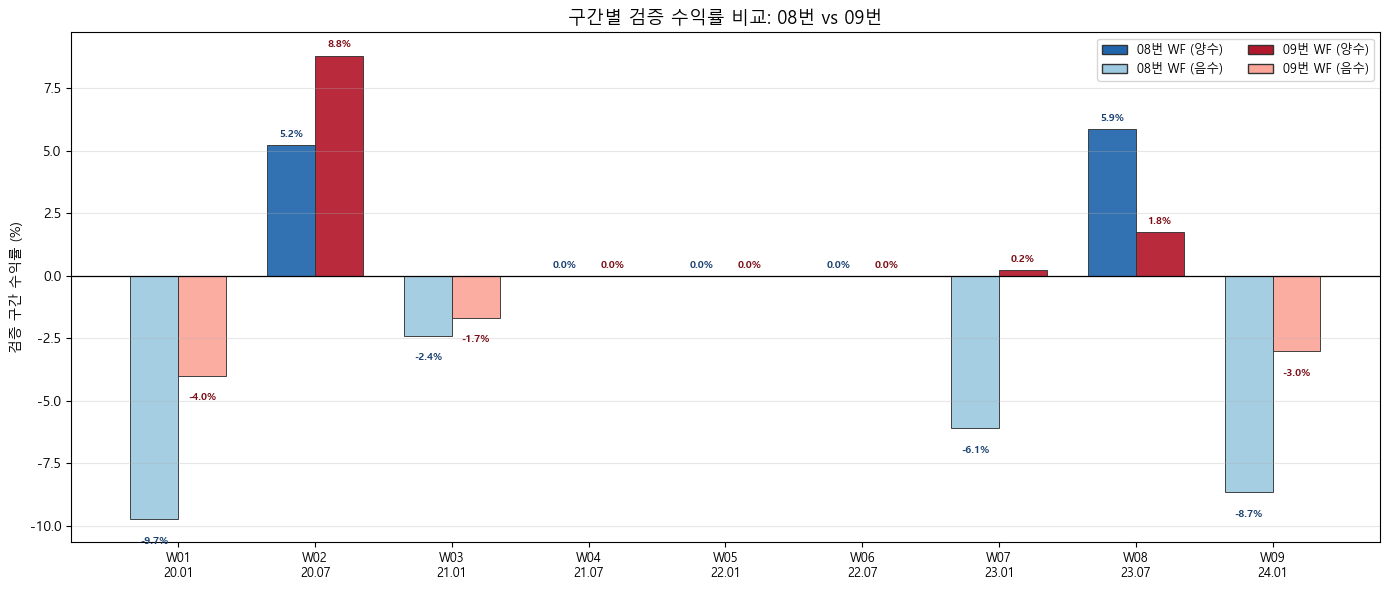


구간별 09번 우위: 5/9개 윈도우
  구간	08번	09번	결과
  W01	-9.7%	-4.0%	09 ↑
  W02	5.2%	8.8%	09 ↑
  W03	-2.4%	-1.7%	09 ↑
  W04	0.0%	0.0%	08 ↑
  W05	0.0%	0.0%	08 ↑
  W06	0.0%	0.0%	08 ↑
  W07	-6.1%	0.2%	09 ↑
  W08	5.9%	1.8%	08 ↑
  W09	-8.7%	-3.0%	09 ↑


In [9]:
n_windows = min(len(wf08['windows']), len(wf09['windows']))
labels    = [f"W{i+1:02d}\n{w['test_start'].strftime('%y.%m')}" for i, w in enumerate(wf09['windows'][:n_windows])]

rets_08 = []
rets_09 = []
for w08, w09 in zip(wf08['windows'][:n_windows], wf09['windows'][:n_windows]):
    r08 = (w08['test_value'].iloc[-1] / w08['test_value'].iloc[0] - 1) * 100 \
          if w08['test_value'] is not None and len(w08['test_value']) > 0 else 0
    r09 = (w09['test_value'].iloc[-1] / w09['test_value'].iloc[0] - 1) * 100 \
          if w09['test_value'] is not None and len(w09['test_value']) > 0 else 0
    rets_08.append(r08)
    rets_09.append(r09)

x = np.arange(n_windows)
w_bar = 0.35

# 전략별 색상 계열 고정
# 08번: 파란 계열 (양수=진파랑 / 음수=연파랑)
# 09번: 빨간 계열 (양수=진빨강 / 음수=연분홍)
C08_POS, C08_NEG = '#2166ac', '#9ecae1'
C09_POS, C09_NEG = '#b2182b', '#fca69a'

fig, ax = plt.subplots(figsize=(14, 6))

bars08 = ax.bar(x - w_bar/2, rets_08, w_bar,
                color=[C08_POS if r >= 0 else C08_NEG for r in rets_08],
                alpha=0.92, edgecolor='#333333', linewidth=0.7,
                label='08번 WF')
bars09 = ax.bar(x + w_bar/2, rets_09, w_bar,
                color=[C09_POS if r >= 0 else C09_NEG for r in rets_09],
                alpha=0.92, edgecolor='#333333', linewidth=0.7,
                label='09번 WF (부분 매수/매도)')

ax.axhline(0, color='black', linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('검증 구간 수익률 (%)')
ax.set_title('구간별 검증 수익률 비교: 08번 vs 09번', fontsize=13)

# 범례: 색상 의미 설명 포함
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=C08_POS, edgecolor='#333333', label='08번 WF (양수)'),
    Patch(facecolor=C08_NEG, edgecolor='#333333', label='08번 WF (음수)'),
    Patch(facecolor=C09_POS, edgecolor='#333333', label='09번 WF (양수)'),
    Patch(facecolor=C09_NEG, edgecolor='#333333', label='09번 WF (음수)'),
]
ax.legend(handles=legend_handles, fontsize=9, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# 수치 레이블
for bar, val in zip(bars08, rets_08):
    ypos = val + 0.25 if val >= 0 else val - 0.7
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1f}%', ha='center', va=va, fontsize=7.5,
            color='#1a4070', fontweight='bold')
for bar, val in zip(bars09, rets_09):
    ypos = val + 0.25 if val >= 0 else val - 0.7
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1f}%', ha='center', va=va, fontsize=7.5,
            color='#7a0c15', fontweight='bold')

plt.tight_layout()
plt.show()

# 08 vs 09 구간별 승패
wins = sum(1 for r8, r9 in zip(rets_08, rets_09) if r9 > r8)
print(f'\n구간별 09번 우위: {wins}/{n_windows}개 윈도우')
print('  구간\t08번\t09번\t결과')
for i, (r8, r9) in enumerate(zip(rets_08, rets_09)):
    result = '09 ↑' if r9 > r8 else '08 ↑'
    print(f'  W{i+1:02d}\t{r8:.1f}%\t{r9:.1f}%\t{result}')

---
## 정리

### 08번 vs 09번 핵심 차이 요약

| 관찰 | 08번 | 09번 | 해석 |
|------|------|------|------|
| 진입 비중 | 이산값 (50/70/100%) | 연속값 (30~100%) | ADX 강할 때만 크게 베팅 |
| 하락 대응 | 즉시 전량 청산 | WEAK_BEAR → 30% 유지 | 단기 변동에 덜 반응 |
| WF 파라미터 | 1D (threshold만) | 2D (threshold + scale) | 시장 상황별 리스크 조절 가능 |

### 어떤 시장에서 유리한가?

| 시장 상황 | 09번이 유리 | 이유 |
|-----------|------------|------|
| 추세 변동 큰 구간 (2022년 하락장) | ✅ | 단계적 청산으로 손실 제한 |
| ADX 중간값 (20~30) 횡보 | ✅ | 비중 30~60%로 적절히 참여 |
| 강한 단방향 상승 (2020년) | ❌ | 진입 비중 낮아 수익 일부 놓침 |

### 다음 개선 방향

```
1. weak_bear_size 최적화: Walk-Forward에 포함 (현재 고정값 0.3)
2. 피라미딩 추가: 포지션 수익 시 비중 증가 (adx_ratio 상향 재조정)
3. 다중 종목: 삼성전자 외 다른 종목에 적용 → 전략 범용성 검증
4. 변동성 기반 포지션 사이징: ATR로 포지션 크기 조절 (Kelly Criterion)
```